# 02 – Exploratory Data Analysis & Knowledge Discovery

Master's Thesis Notebook

## Objectives
- Explore dataset
- Produce publication-quality figures
- Prepare for statistical validation

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH='data/processed/clean_dataset.csv'
REPORT_DIR=Path('reports/EDA')
FIG_DIR=REPORT_DIR/'figures'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def plot_categorical(df,column,title,folder):
    counts=df[column].value_counts(dropna=False)
    plt.figure(figsize=(8,5))
    plt.bar(counts.index.astype(str),counts.values)
    plt.title(title)
    plt.xticks(rotation=30,ha='right')
    plt.tight_layout()
    folder.mkdir(parents=True,exist_ok=True)
    plt.savefig(folder/f'{column}.png',dpi=300)
    plt.show()

def summary_table(df):
    return pd.DataFrame({'dtype':df.dtypes.astype(str),
                         'missing':df.isna().sum(),
                         'unique':df.nunique()})


In [3]:
df=pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())
display(summary_table(df))
summary_table(df).to_excel(REPORT_DIR/'dataset_summary.xlsx')


(195, 74)


,Timestamp,consent,age_group,gender,education_level,primary_device,shopping_motivation,decision_speed,price_sensitivity,review_importance,...,mobile_price_display,mobile_filter_location,mobile_quick_view,mobile_review_display,mobile_sticky_header,mobile_touch_size,expects_device_adaptation,adaptation_comfort,delight_factors,frustration_points
0,20/01/2026 17:24:30,Yes,18-24,Male,Graduate,Smartphone,Research (I like exploring products and learni...,Quick (5-15 minutes - I know what I want),Moderately important (I balance price and qual...,Sometimes read reviews (For certain product ty...,...,Strike-through Original (Shows original price ...,Drawer Overlay (Slides in from the side when c...,Slide-Up Panel (Preview product details in a s...,Collapsible Sections (Reviews can be expanded ...,No (Header scrolls away with content),"Large (Easier to tap, less content visible)",Somewhat Different (Adapted but recognizable),3,NaN,NaN
1,20/01/2026 17:27:08,Yes,25-34,Female,Graduate,Smartphone,Deal-hunting (I look for sales and discounts),Moderate (15-30 minutes - I compare a few opti...,Moderately important (I balance price and qual...,Often read reviews (For most purchases),...,Strike-through Original (Shows original price ...,Drawer Overlay (Slides in from the side when c...,Slide-Up Panel (Preview product details in a s...,Collapsible Sections (Reviews can be expanded ...,Yes (Header stays at top while scrolling),"Standard (Normal size, more content visible)",Somewhat Different (Adapted but recognizable),5,the website or the application should be user-...,when the description or the photo of the produ...
2,20/01/2026 17:38:38,Yes,18-24,Male,Graduate,Smartphone,Entertainment (I browse for fun and enjoyment),Impulsive (Less than 5 minutes - I decide quic...,Somewhat unimportant (Price matters but isn't ...,Sometimes read reviews (For certain product ty...,...,Simple Display (Price is visible but not empha...,Drawer Overlay (Slides in from the side when c...,Slide-Up Panel (Preview product details in a s...,Summary Only (Average rating and total count),Yes (Header stays at top while scrolling),"Large (Easier to tap, less content visible)",Somewhat Different (Adapted but recognizable),4,It allows me to buy items new to me and it sav...,Lack of stock or high prices for low quality
3,20/01/2026 17:41:19,Yes,25-34,Female,Postgraduate,Smartphone,Need-based (I shop when I need something speci...,Research-heavy (30+ minutes - I thoroughly res...,Moderately important (I balance price and qual...,Often read reviews (For most purchases),...,Simple Display (Price is visible but not empha...,Drawer Overlay (Slides in from the side when c...,No Quick View (I prefer to go to the full prod...,Collapsible Sections (Reviews can be expanded ...,Yes (Header stays at top while scrolling),"Large (Easier to tap, less content visible)","Yes, Very Different (Completely different desi...",5,Search bar - filters - colors of the pages,If I can’t sea the prices clearly or no filter...
4,20/01/2026 17:46:10,Yes,25-34,Female,Graduate,Smartphone,Research (I like exploring products and learni...,Moderate (15-30 minutes - I compare a few opti...,Somewhat unimportant (Price matters but isn't ...,Always read reviews (I won't buy without check...,...,Strike-through Original (Shows original price ...,Full-Screen Overlay (Displayed across screen),Slide-Up Panel (Preview product details in a s...,Summary Only (Average rating and total count),Yes (Header stays at top while scrolling),"Large (Easier to tap, less content visible)","Yes, Very Different (Completely different desi...",5,Very easy,Complicated websites


,dtype,missing,unique
Timestamp,object,0,195
consent,object,0,1
age_group,object,0,4
gender,object,0,2
education_level,object,0,5
...,...,...,...
mobile_touch_size,object,0,3
expects_device_adaptation,object,0,4
adaptation_comfort,int64,0,5
delight_factors,object,66,129


## Demographics

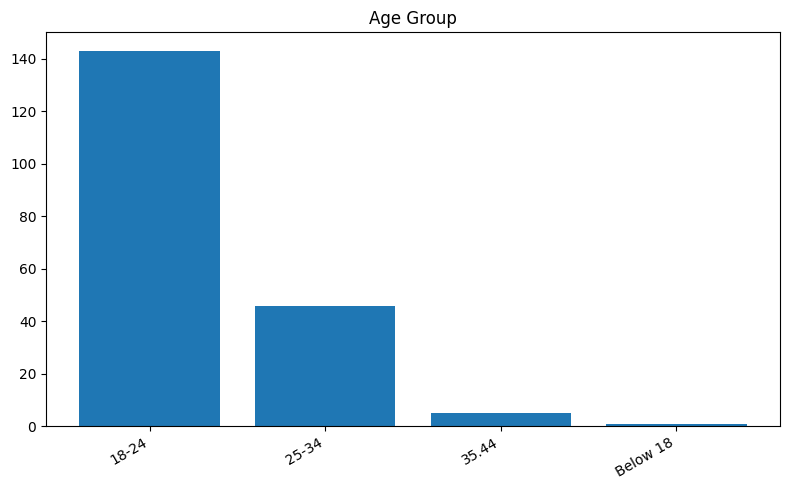

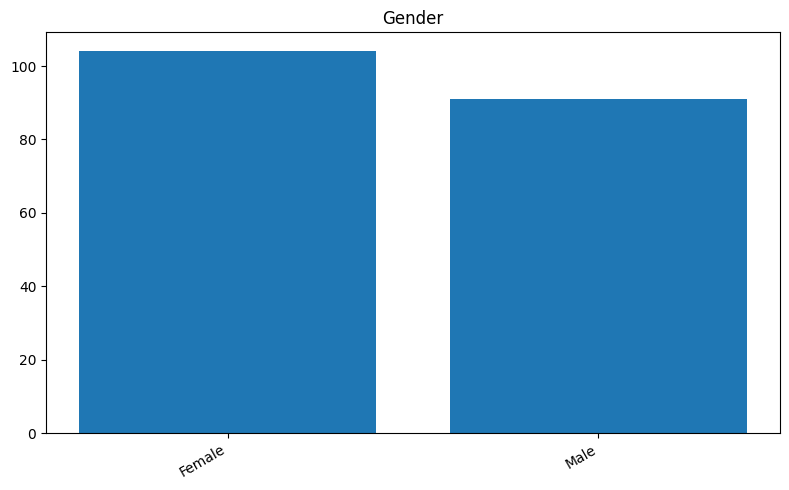

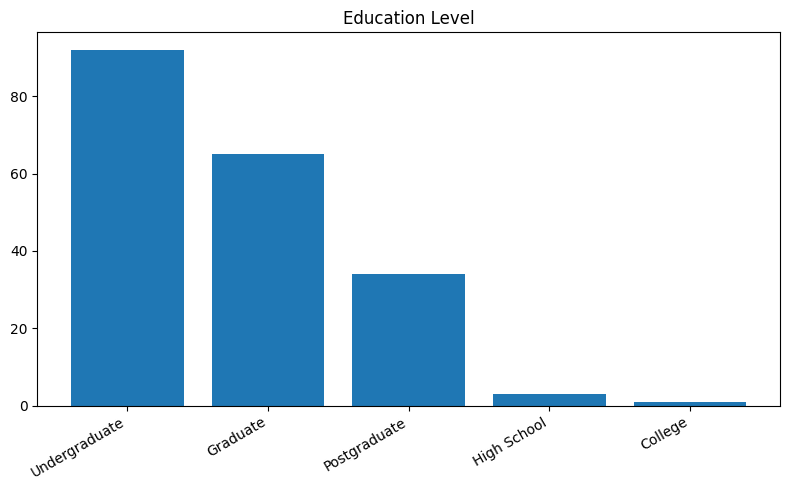

In [4]:
for c in ['age_group','gender','education_level']:
    plot_categorical(df,c,c.replace('_',' ').title(),FIG_DIR/'demographics')


## User Context

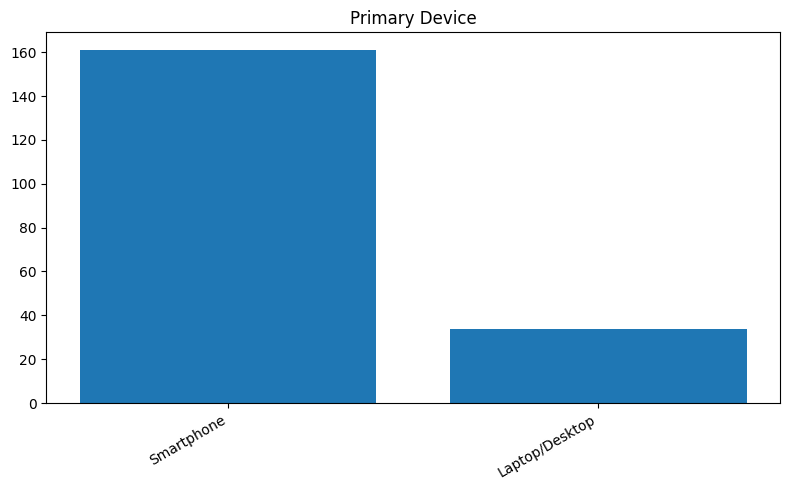

/var/folders/s4/58jq93_9755219wlv3wwtzq40000gn/T/ipykernel_12060/1043396820.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


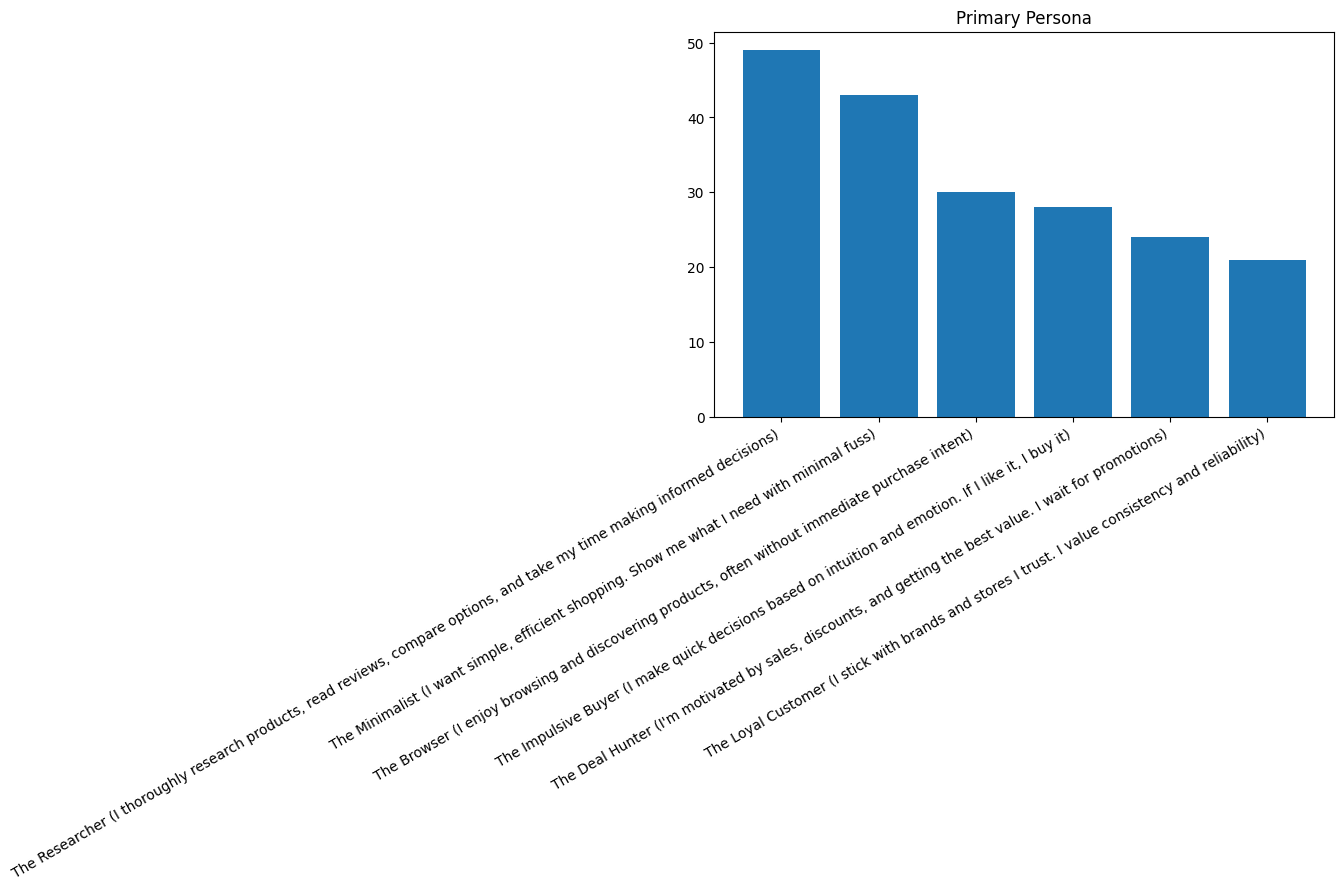

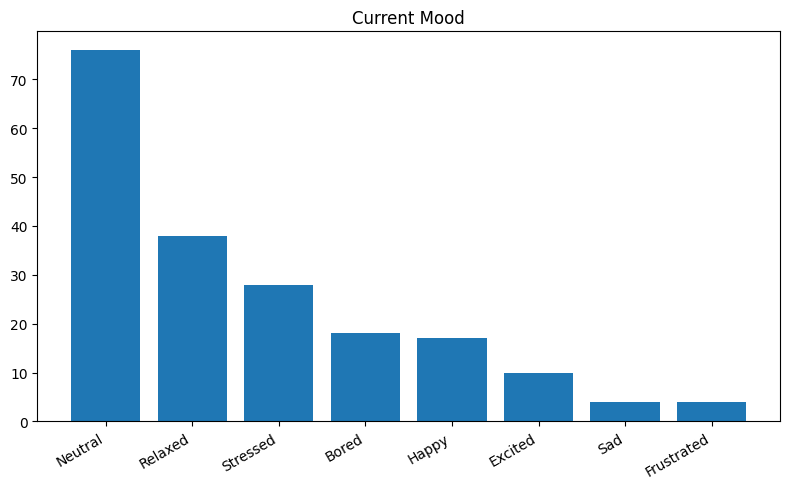

In [5]:
for c in ['primary_device','primary_persona','current_mood']:
    plot_categorical(df,c,c.replace('_',' ').title(),FIG_DIR/'context')


## Shopping Behaviour

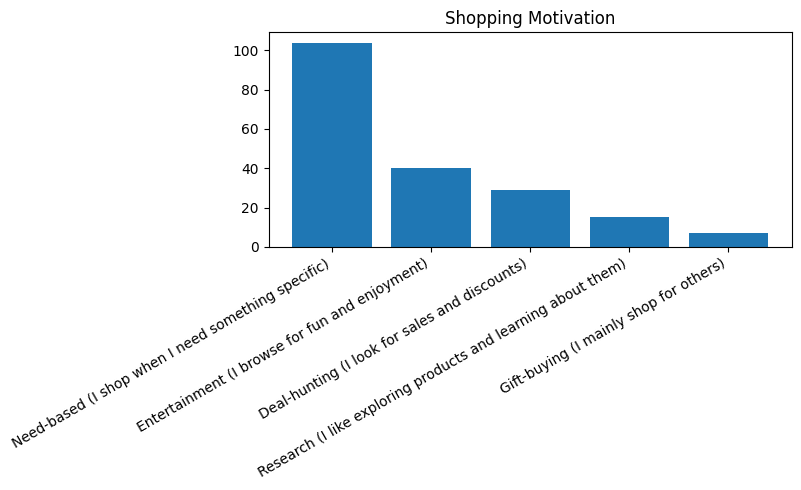

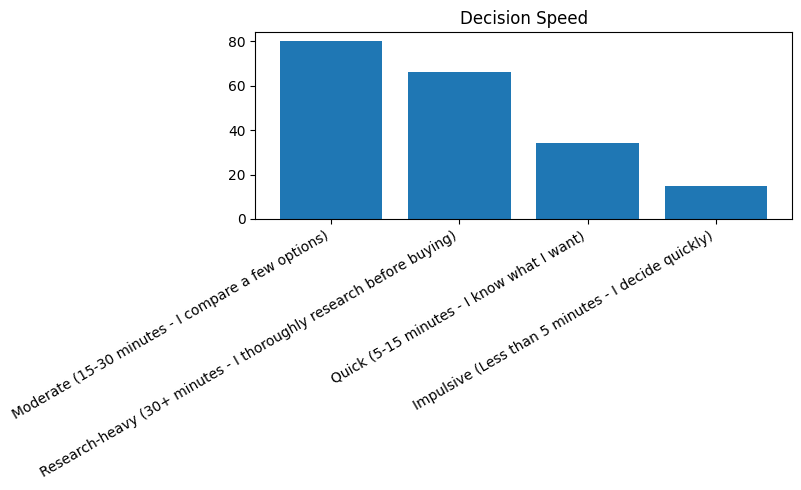

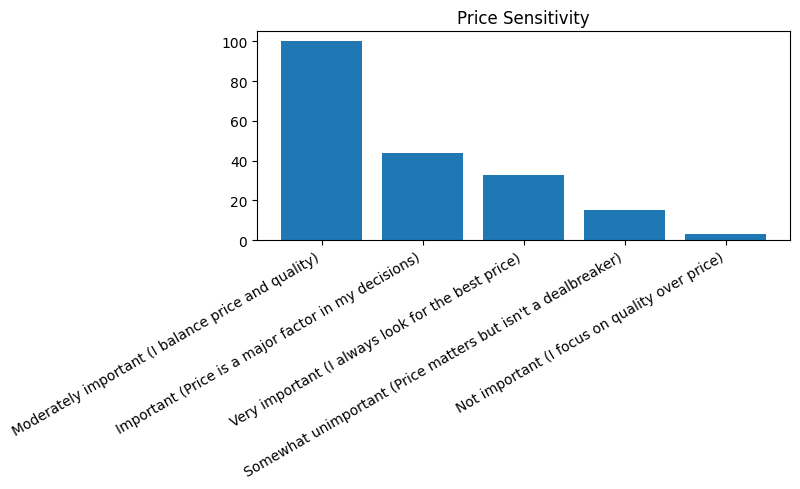

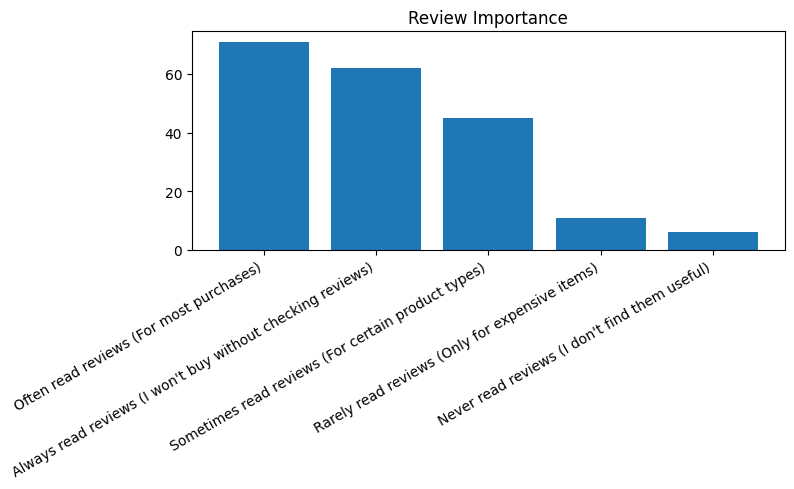

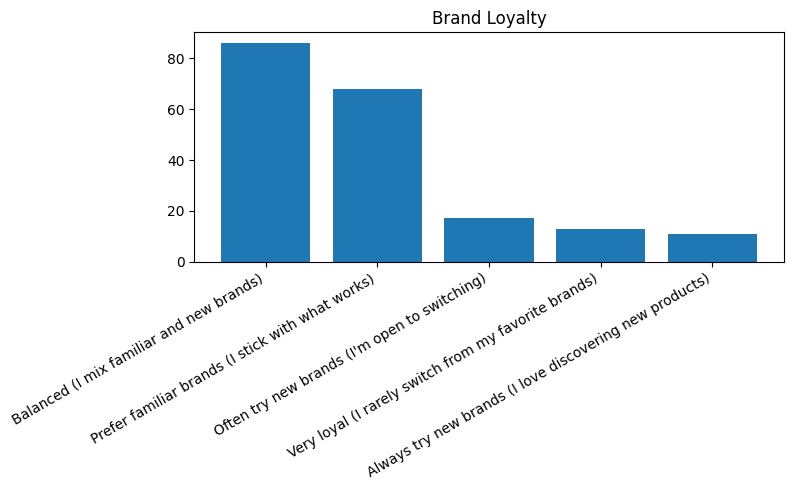

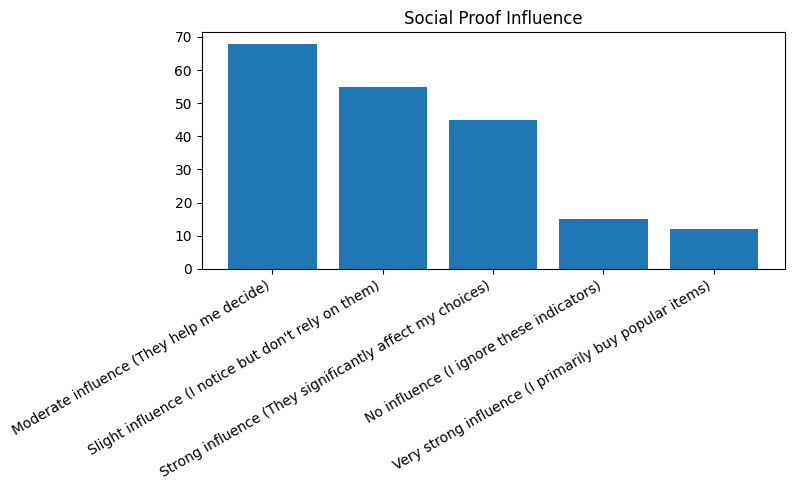

In [6]:
for c in ['shopping_motivation','decision_speed','price_sensitivity',
'review_importance','brand_loyalty','social_proof_influence']:
    plot_categorical(df,c,c.replace('_',' ').title(),FIG_DIR/'shopping')


## End of Part 1
Next: Personality, Global UI, Desktop, Mobile, Cross-analysis, Cramer's V.